In [11]:
from sentence_transformers import SentenceTransformer, util
import Levenshtein
from transformers import BertTokenizer, BertModel
import torch
import re
import torch
import nltk
import numpy as np
from gensim.models import KeyedVectors, FastText
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import BertTokenizer, BertModel
import spacy
from sentence_transformers import SentenceTransformer
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
from nltk import CFG

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ALEX\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ALEX\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ALEX\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [12]:
# Λεξικό συνωνύμων / παραφρασμένων εκφράσεων
grammar = CFG.fromstring("""
S -> NP VP
NP -> PN | Det N N N
VP -> V NP
Det -> 'our'
PN -> 'Today'
N -> 'dragon' | 'boat' | 'festival'
V -> 'is'
""")


parser1 = nltk.ChartParser(grammar)

grammar = CFG.fromstring("""
S -> InfVP
InfVP -> TO V NP PP
NP -> Pro | Poss Adj N
PP -> P NP
TO -> 'to'
V -> 'enjoy'|
Pro -> 'it'
Poss -> 'my'
Adj -> 'deepest' |
N -> 'wishes'
P -> 'as'
""")

parser2 = nltk.ChartParser(grammar)


In [13]:
# Συνάρτηση για ανακατασκευή


# Κείμενο εισόδου
text1 = "Today is our dragon boat festival"
text2 = "to enjoy it as my deepest wishes"


tokens1 = text1.split()
tokens2 = text2.split()

for tree in parser1.parse(tokens1):
    tree.pretty_print()

for tree in parser2.parse(tokens2):
    tree.pretty_print()



replacements = {
    'dragon': 'legendary',
    'festival': 'celebration',
    'enjoy': 'have fun to',
    'deepest' : 'dearest'
}



text1_b =  ' '.join([replacements.get(word, word) for word in text1.split()])


text2_b = ' '.join([replacements.get(word, word) for word in text2.split()])




# Εφαρμογή παραφραστικού αλγορίθμου
print("🔹 Original 1:", text1)
print("🔁 Paraphrased 1:", text1_b)
print()
print("🔹 Original 2:", text2)
print("🔁 Paraphrased 2:", text2_b)

       S                          
   ____|___                        
  |        VP                     
  |     ___|____                   
  NP   |        NP                
  |    |    ____|____________      
  PN   V  Det   N     N      N    
  |    |   |    |     |      |     
Today  is our dragon boat festival

                S                          
                |                           
              InfVP                        
  ______________|_________                  
 |    |    |              PP               
 |    |    |     _________|_____            
 |    |    NP   |               NP         
 |    |    |    |     __________|______     
 TO   V   Pro   P   Poss       Adj     N   
 |    |    |    |    |          |      |    
 to enjoy  it   as   my      deepest wishes

🔹 Original 1: Today is our dragon boat festival
🔁 Paraphrased 1: Today is our legendary boat celebration

🔹 Original 2: to enjoy it as my deepest wishes
🔁 Paraphrased 2: to have fun to it as

In [14]:
def get_bert_emb(text):
    toks = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        out = bert_model(**toks)
    return out.last_hidden_state.mean(dim=1).cpu().numpy()[0]

# Συνάρτηση μέσου όρου embeddings λέξεων για word-level μεθόδους
def mean_embedding(words, model_wv):
    vecs = [model_wv[w] for w in words if w in model_wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model_wv.vector_size)


def levenshtein_similarity(text1, text2):
    # Υπολογισμός της Levenshtein Distance
    lev_distance = Levenshtein.distance(text1, text2)
    # Κανονικοποιημένη ομοιότητα (0 - 1)
    similarity = 1 - lev_distance / max(len(text1), len(text2))
    return similarity

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')


In [15]:
originals, paraphrases=[],[]


originals.append(text1)
originals.append(text2)

paraphrases.append(text1_b)
paraphrases.append(text2_b)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = word_tokenize(text)
    lemmas = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and t.isalpha()]
    return ' '.join(lemmas)
    
corpus = [preprocess(t) for t in originals + paraphrases]

w2v = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=1)

# Εκπαίδευση FastText
ft = FastText(vector_size=100, window=3, min_count=1)
ft.build_vocab(corpus)
ft.train(corpus, total_examples=len(corpus), epochs=5)



all_texts = [preprocess(t) for t in originals+paraphrases]
tfidf = TfidfVectorizer()
tfidf.fit(all_texts)
vocab = tfidf.get_feature_names_out()


# 4. Υπολογισμός cosine similarity
methods = {}
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

for name, embed_func in [
    ("Word2Vec", lambda txt: mean_embedding(txt.split(), w2v.wv)),
    #("GloVe",  lambda txt: mean_embedding(txt.split(), glove)),
    ("FastText", lambda txt: mean_embedding(txt.split(), ft.wv)),
    ("BERT", get_bert_emb)
]:
    sims = []
    for orig, para in zip(originals, paraphrases):
        emb_o = embed_func(preprocess(orig))
        emb_p = embed_func(preprocess(para))
        sim = cosine_similarity([emb_o], [emb_p])[0][0]
        sims.append(sim)
    methods[name] = sims

    # Sentence-BERT cosine similarity
    sbert_sims = []
    for orig, para in zip(originals, paraphrases):
        emb1 = sbert_model.encode(orig, convert_to_tensor=True)
        emb2 = sbert_model.encode(para, convert_to_tensor=True)
        sim = util.cos_sim(emb1, emb2).item()
        sbert_sims.append(sim)
    methods["cos_sim"] = sbert_sims

    # Levenshtein Distance normalized
    lev_sims = []
    for orig, para in zip(originals, paraphrases):
        lev = levenshtein_similarity(orig, para)

        lev_sims.append(lev)
    methods["Levenshtein"] = lev_sims
# 5. Παρουσίαση Αποτελεσμάτων

print("Cosine similarity (original vs paraphrase) after preprocess:\n")
for name, sims in methods.items():
    print(f"\n– {name}:")
    for i, sim in enumerate(sims, 1):
        print(f"  Pair {i}: similarity = {sim:.4f}")





Cosine similarity (original vs paraphrase) after preprocess:


– Word2Vec:
  Pair 1: similarity = 0.0000
  Pair 2: similarity = 0.0000

– cos_sim:
  Pair 1: similarity = 0.7401
  Pair 2: similarity = 0.8524

– Levenshtein:
  Pair 1: similarity = 0.5641
  Pair 2: similarity = 0.7105

– FastText:
  Pair 1: similarity = 0.7254
  Pair 2: similarity = 0.3463

– BERT:
  Pair 1: similarity = 0.8556
  Pair 2: similarity = 0.7660


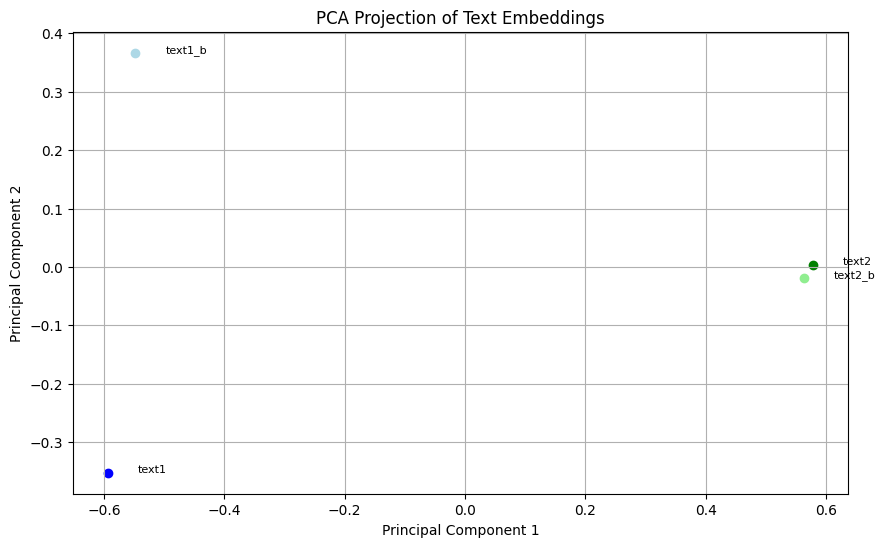

In [22]:


all_texts = [text1] + [text1_b] + [text2] + [text2_b]

labels = [
    'text1',
    'text1_b',
    'text2',
    'text2_b'
]



# Φόρτωση μοντέλου
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(all_texts)

# PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)  # << Εδώ το pca_result ήταν σωστό αλλά μετά καλούσες "reduced"

# Χρώματα για plotting
label_colors = {
    'text1': 'blue',
    'text1_b': 'lightblue',
    'text2': 'green',
    'text2_b': 'lightgreen'
}
colors = [label_colors[label] for label in labels]

# Οπτικοποίηση
plt.figure(figsize=(10, 6))

for i, label in enumerate(labels):
    plt.scatter(reduced[i, 0], reduced[i, 1], color=colors[i])
    plt.text(reduced[i, 0]+0.05, reduced[i, 1], label, fontsize=8)

plt.title("PCA Projection of Text Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()